In [1]:
STUDENT = "Đinh Quốc Bảo - 6351071006"

## 1. Import các thư viện cần thiết

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
from scipy.optimize import linear_sum_assignment

## 2. Tải và chuẩn bị dữ liệu MNIST

In [3]:
print(STUDENT)
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X, y = mnist.data, mnist.target

y = y.astype(int)

n_samples = 10000
indices = np.random.choice(len(X), n_samples, replace=False)
X_sample = X.iloc[indices] if hasattr(X, 'iloc') else X[indices]
y_sample = y.iloc[indices] if hasattr(y, 'iloc') else y[indices]

X_sample = X_sample / 255.0

print(f"Kích thước dữ liệu: {X_sample.shape}")
print(f"Số lượng nhãn: {len(np.unique(y_sample))}")
print(f"Phân bố các nhãn:\n{pd.Series(y_sample).value_counts().sort_index()}")

Đinh Quốc Bảo - 6351071006
Kích thước dữ liệu: (10000, 784)
Số lượng nhãn: 10
Phân bố các nhãn:
class
0     996
1    1137
2     987
3    1046
4     949
5     935
6     933
7    1054
8     985
9     978
Name: count, dtype: int64


## 3. Hiển thị một số ví dụ từ dữ liệu

Đinh Quốc Bảo - 6351071006


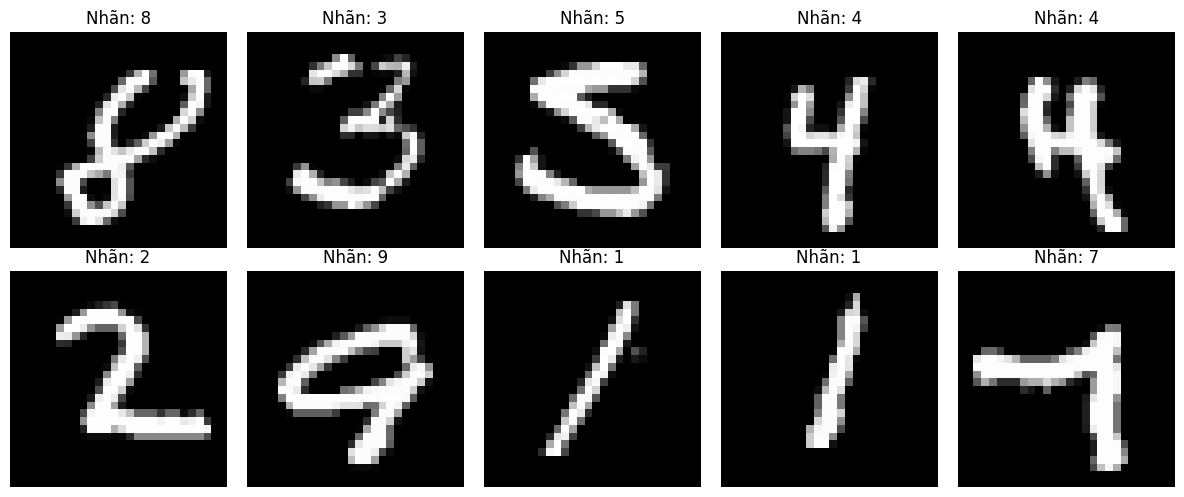

In [4]:
print(STUDENT)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    if hasattr(X_sample, 'iloc'):
        image = X_sample.iloc[i].values.reshape(28, 28)
    else:
        image = X_sample[i].reshape(28, 28)
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Nhãn: {y_sample.iloc[i] if hasattr(y_sample, "iloc") else y_sample[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Thực hiện thuật toán K-Means

In [5]:
print(STUDENT)
n_clusters = 10

print(f"Đang thực hiện K-Means với {n_clusters} cụm...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10, max_iter=300, verbose=1)
cluster_labels = kmeans.fit_predict(X_sample)

print("\nHoàn thành gom cụm!")
print(f"Inertia (tổng bình phương khoảng cách): {kmeans.inertia_:.2f}")

Đinh Quốc Bảo - 6351071006
Đang thực hiện K-Means với 10 cụm...
Initialization complete
Iteration 0, inertia 650745.1331180307.
Iteration 1, inertia 416862.2023957419.
Iteration 2, inertia 405618.8433172268.
Iteration 3, inertia 401998.8806278306.
Iteration 4, inertia 400741.73218799534.
Iteration 5, inertia 400002.4727508135.
Iteration 6, inertia 399442.47936982225.
Iteration 7, inertia 398954.7390098567.
Iteration 8, inertia 398455.3437495862.
Iteration 9, inertia 397912.43996992183.
Iteration 10, inertia 397385.2938032467.
Iteration 11, inertia 396798.086703407.
Iteration 12, inertia 396334.84909147903.
Iteration 13, inertia 395981.63450752344.
Iteration 14, inertia 395721.17700210324.
Iteration 15, inertia 395547.7981828759.
Iteration 16, inertia 395404.2666028362.
Iteration 17, inertia 395267.42608248483.
Iteration 18, inertia 395162.13177203404.
Iteration 19, inertia 395060.64964246773.
Iteration 20, inertia 394953.89150635316.
Iteration 21, inertia 394855.70909810474.
Iteration 

## 5. Ánh xạ cụm với nhãn thực tế

In [6]:
print(STUDENT)
def map_clusters_to_labels(cluster_labels, true_labels):
    n_clusters = len(np.unique(cluster_labels))
    n_classes = len(np.unique(true_labels))
    cost_matrix = np.zeros((n_clusters, n_classes))

    for i in range(n_clusters):
        for j in range(n_classes):
            cost_matrix[i, j] = -np.sum((cluster_labels == i) & (true_labels == j))

    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    mapping = {row: col for row, col in zip(row_ind, col_ind)}

    mapped_labels = np.array([mapping[label] for label in cluster_labels])

    return mapped_labels, mapping

mapped_labels, cluster_mapping = map_clusters_to_labels(cluster_labels, y_sample)

print("Ánh xạ cụm -> nhãn:")
for cluster, label in sorted(cluster_mapping.items()):
    print(f"  Cụm {cluster} -> Chữ số {label}")

Đinh Quốc Bảo - 6351071006
Ánh xạ cụm -> nhãn:
  Cụm 0 -> Chữ số 0
  Cụm 1 -> Chữ số 5
  Cụm 2 -> Chữ số 9
  Cụm 3 -> Chữ số 7
  Cụm 4 -> Chữ số 2
  Cụm 5 -> Chữ số 3
  Cụm 6 -> Chữ số 1
  Cụm 7 -> Chữ số 4
  Cụm 8 -> Chữ số 8
  Cụm 9 -> Chữ số 6


## 6. Đánh giá kết quả gom cụm

In [7]:
print(STUDENT)
ari = adjusted_rand_score(y_sample, cluster_labels)
nmi = normalized_mutual_info_score(y_sample, cluster_labels)
silhouette = silhouette_score(X_sample, cluster_labels, sample_size=5000)
accuracy = np.mean(mapped_labels == y_sample)

print("=" * 50)
print("KẾT QUẢ ĐÁNH GIÁ GOM CỤM")
print("=" * 50)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")
print(f"Accuracy (sau khi ánh xạ): {accuracy:.4f} ({accuracy*100:.2f}%)")
print("=" * 50)

Đinh Quốc Bảo - 6351071006
KẾT QUẢ ĐÁNH GIÁ GOM CỤM
Adjusted Rand Index (ARI): 0.3713
Normalized Mutual Information (NMI): 0.5013
Silhouette Score: 0.0581
Accuracy (sau khi ánh xạ): 0.5467 (54.67%)


## 7. Ma trận nhầm lẫn (Confusion Matrix)

Đinh Quốc Bảo - 6351071006


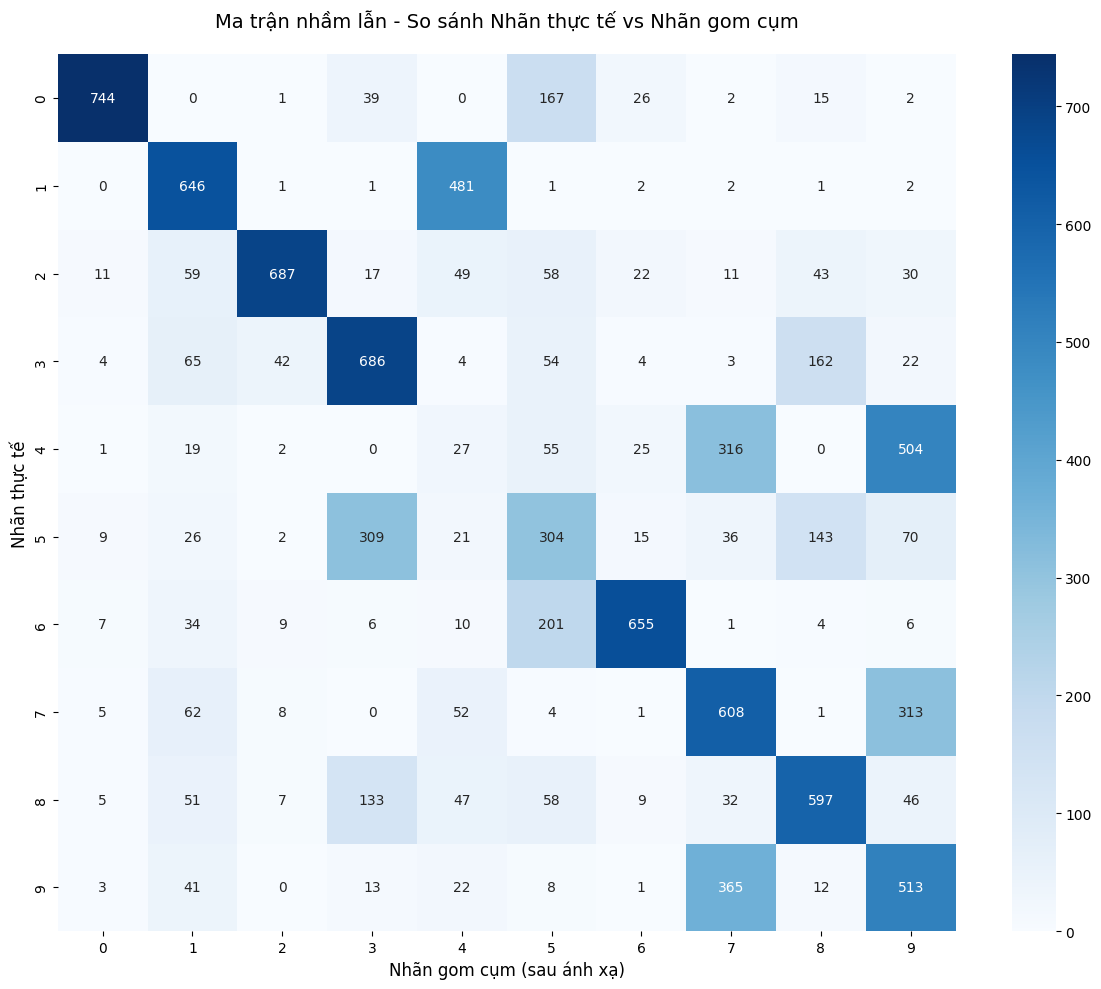


Độ chính xác theo từng chữ số:
  Chữ số 0: 0.7470 (74.70%)
  Chữ số 1: 0.5682 (56.82%)
  Chữ số 2: 0.6960 (69.60%)
  Chữ số 3: 0.6558 (65.58%)
  Chữ số 4: 0.0285 (2.85%)
  Chữ số 5: 0.3251 (32.51%)
  Chữ số 6: 0.7020 (70.20%)
  Chữ số 7: 0.5769 (57.69%)
  Chữ số 8: 0.6061 (60.61%)
  Chữ số 9: 0.5245 (52.45%)


In [8]:
print(STUDENT)
cm = confusion_matrix(y_sample, mapped_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Ma trận nhầm lẫn - So sánh Nhãn thực tế vs Nhãn gom cụm', fontsize=14, pad=20)
plt.ylabel('Nhãn thực tế', fontsize=12)
plt.xlabel('Nhãn gom cụm (sau ánh xạ)', fontsize=12)
plt.tight_layout()
plt.show()

print("\nĐộ chính xác theo từng chữ số:")
for i in range(10):
    digit_accuracy = cm[i, i] / cm[i, :].sum() if cm[i, :].sum() > 0 else 0
    print(f"  Chữ số {i}: {digit_accuracy:.4f} ({digit_accuracy*100:.2f}%)")

## 8. Trực quan hóa kết quả bằng PCA

Đinh Quốc Bảo - 6351071006
Phương sai được giải thích: 0.1689


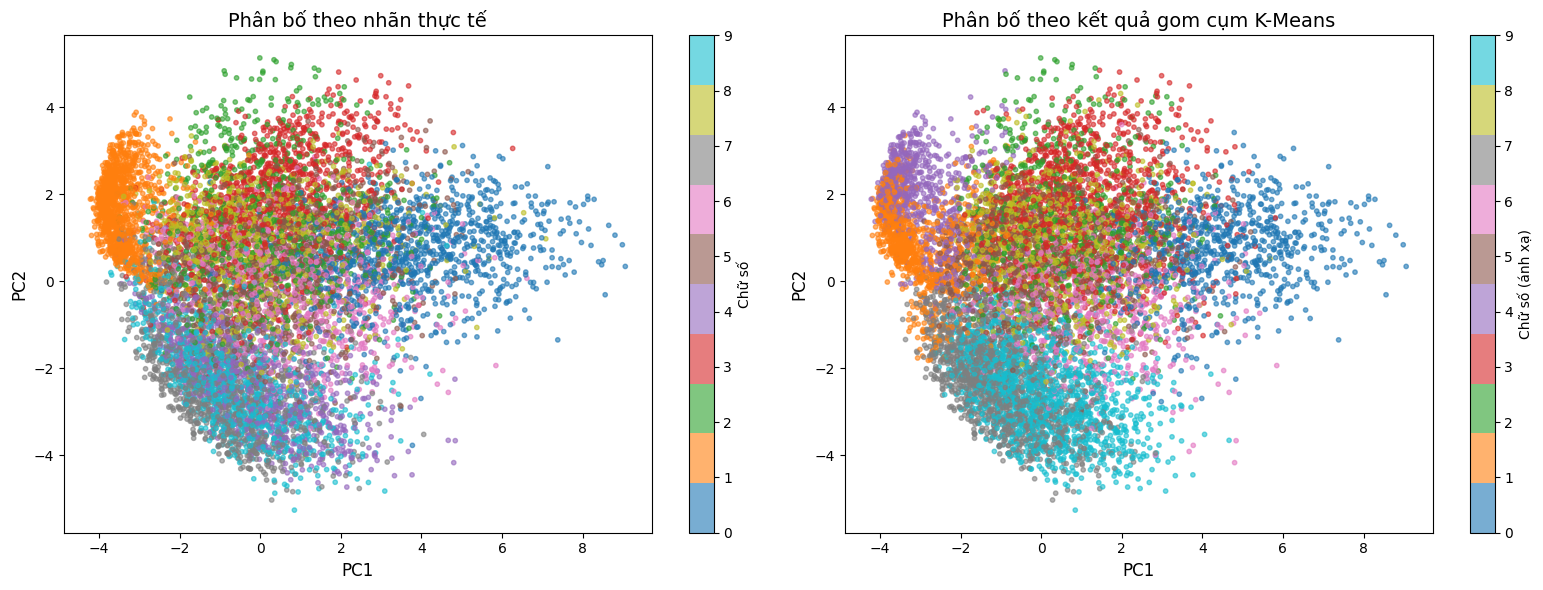

In [9]:
print(STUDENT)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

print(f"Phương sai được giải thích: {pca.explained_variance_ratio_.sum():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample, cmap='tab10', alpha=0.6, s=10)
axes[0].set_title('Phân bố theo nhãn thực tế', fontsize=14)
axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
plt.colorbar(scatter1, ax=axes[0], label='Chữ số')

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=mapped_labels, cmap='tab10', alpha=0.6, s=10)
axes[1].set_title('Phân bố theo kết quả gom cụm K-Means', fontsize=14)
axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)
plt.colorbar(scatter2, ax=axes[1], label='Chữ số (ánh xạ)')

plt.tight_layout()
plt.show()

## 9. Hiển thị ví dụ từ mỗi cụm

Đinh Quốc Bảo - 6351071006


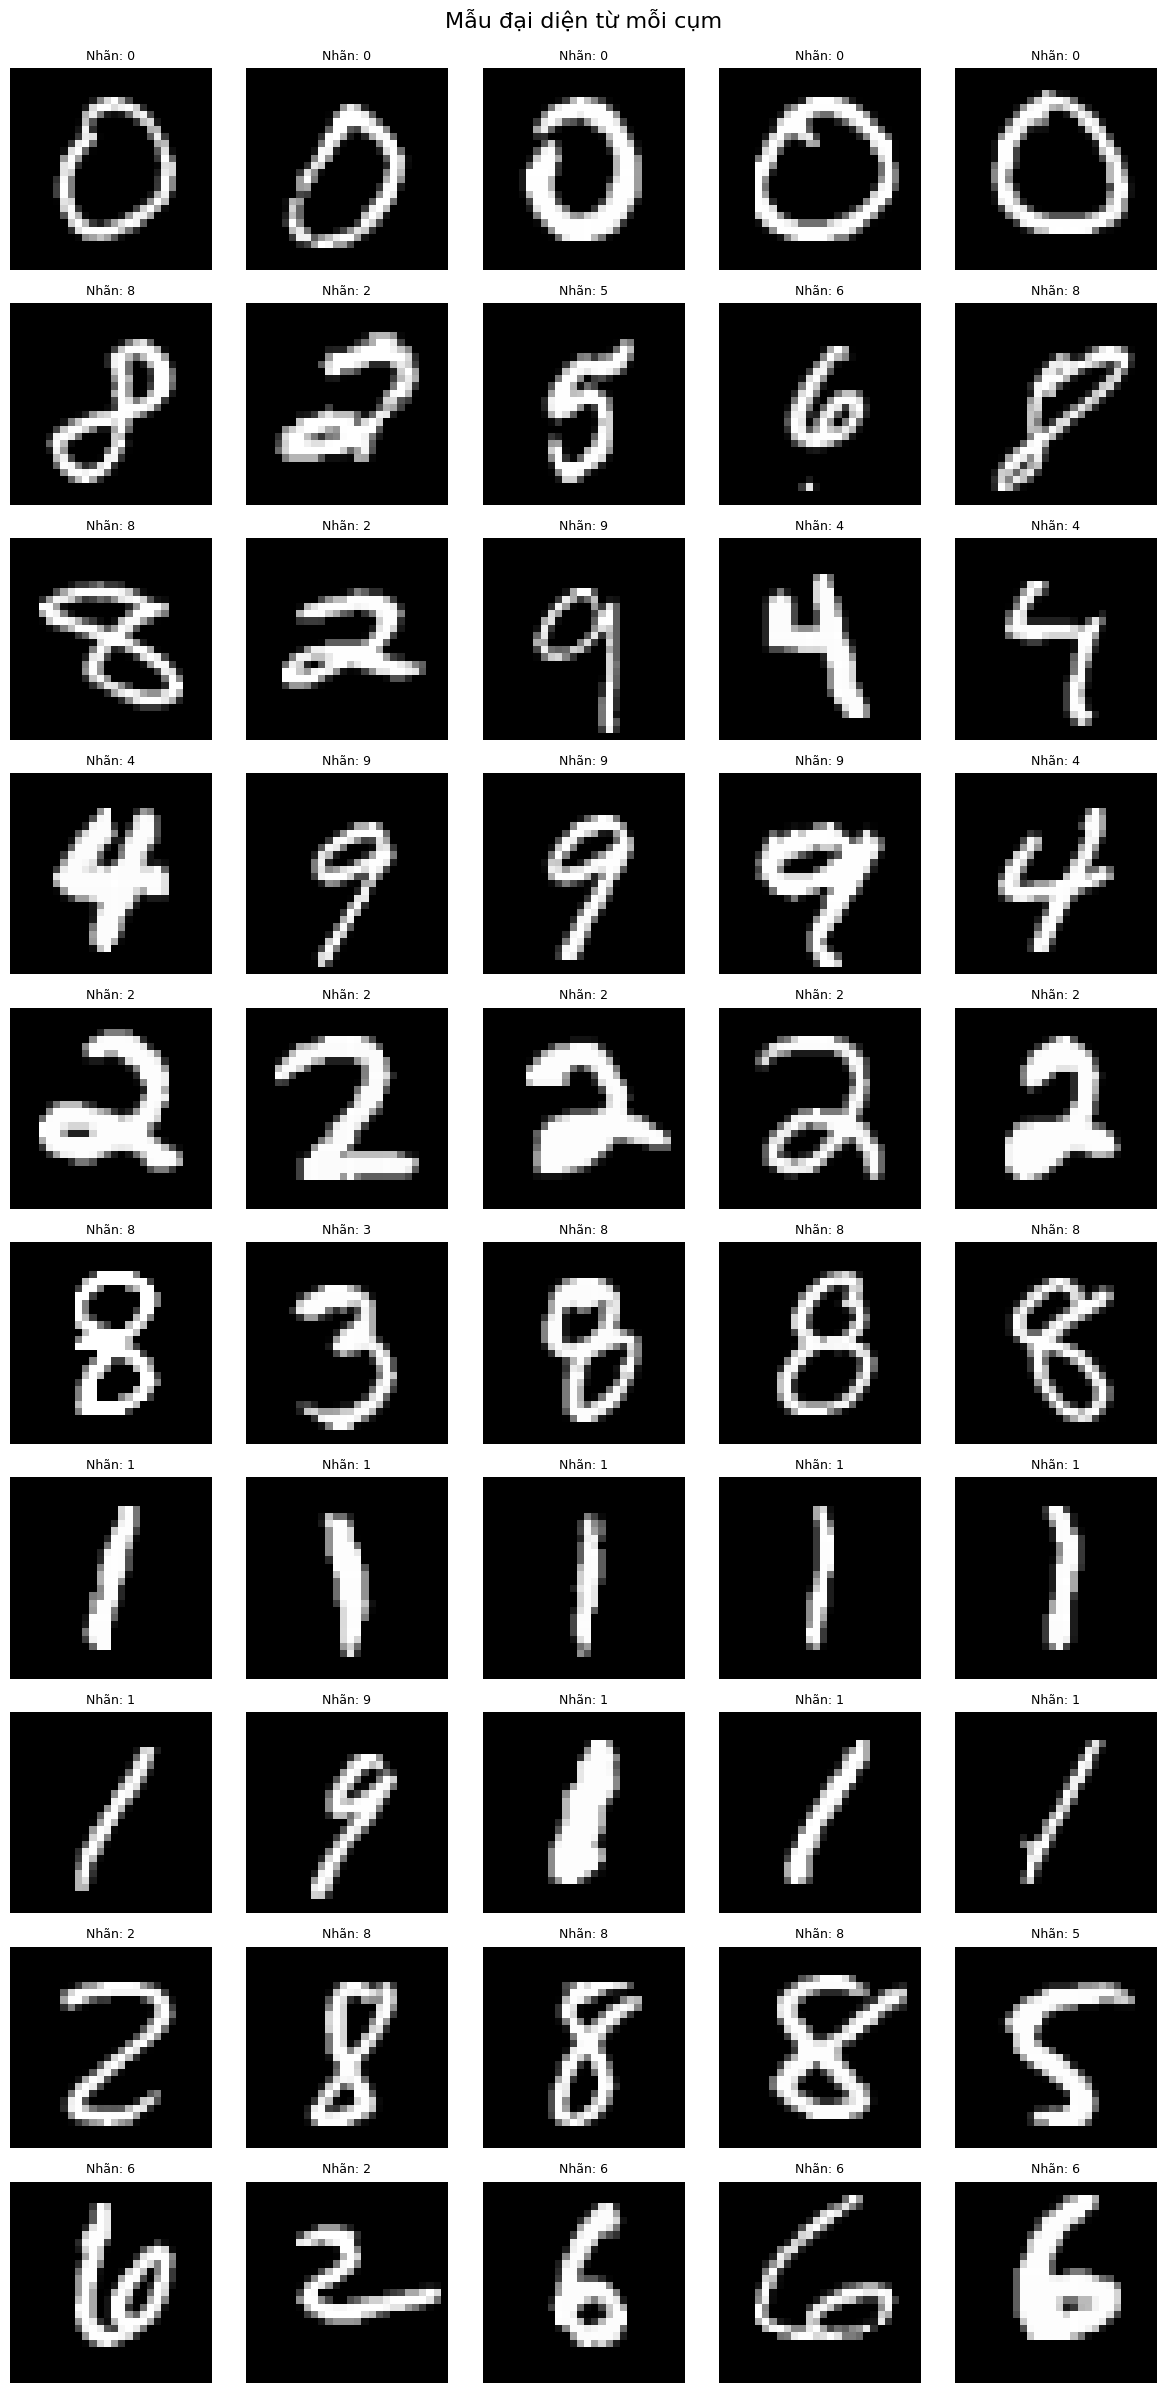

In [10]:
print(STUDENT)
fig, axes = plt.subplots(10, 5, figsize=(12, 24))

for cluster in range(10):
    cluster_indices = np.where(cluster_labels == cluster)[0]

    sample_indices = np.random.choice(cluster_indices, min(5, len(cluster_indices)), replace=False)

    for i, idx in enumerate(sample_indices):
        if hasattr(X_sample, 'iloc'):
            image = X_sample.iloc[idx].values.reshape(28, 28)
        else:
            image = X_sample[idx].reshape(28, 28)

        axes[cluster, i].imshow(image, cmap='gray')
        true_label = y_sample.iloc[idx] if hasattr(y_sample, 'iloc') else y_sample[idx]
        axes[cluster, i].set_title(f'Nhãn: {true_label}', fontsize=9)
        axes[cluster, i].axis('off')

    axes[cluster, 0].set_ylabel(f'Cụm {cluster}\n(→{cluster_mapping[cluster]})',
                                fontsize=10, rotation=0, labelpad=40, va='center')

plt.suptitle('Mẫu đại diện từ mỗi cụm', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

## 10. Phân tích các lỗi gom cụm

Đinh Quốc Bảo - 6351071006
Số lượng mẫu bị gom cụm sai: 4533/10000 (45.33%)


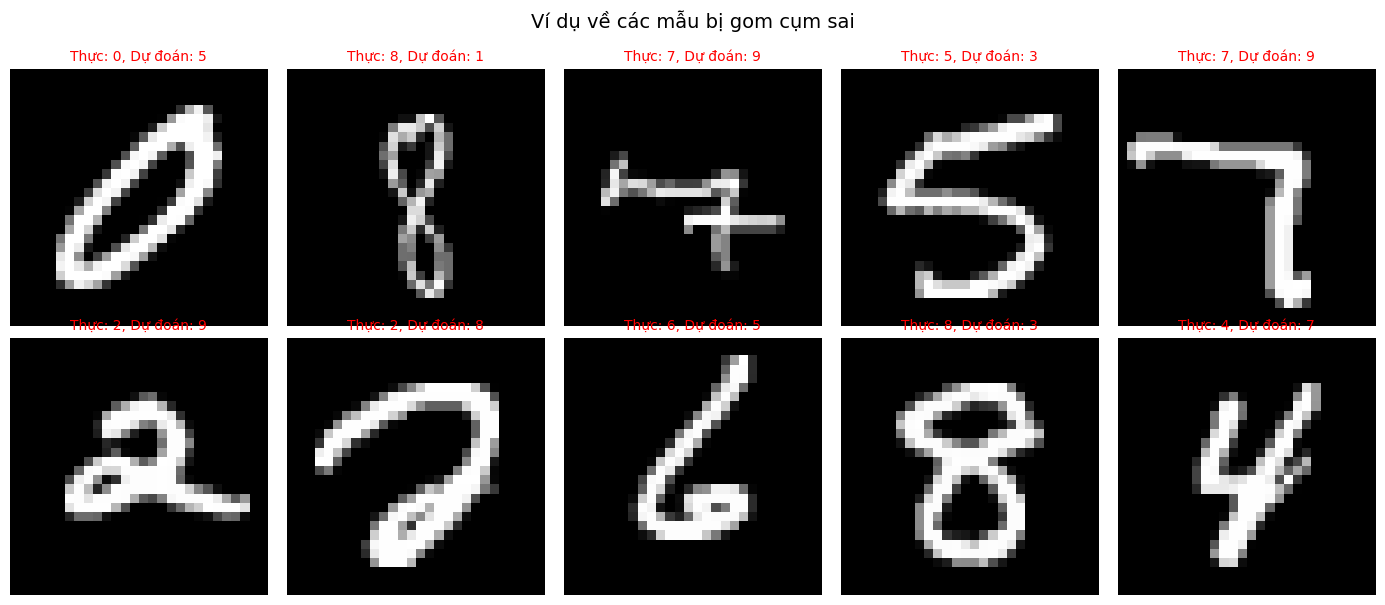

In [11]:
print(STUDENT)
misclassified = mapped_labels != y_sample
n_misclassified = np.sum(misclassified)

print(f"Số lượng mẫu bị gom cụm sai: {n_misclassified}/{len(y_sample)} ({n_misclassified/len(y_sample)*100:.2f}%)")

if n_misclassified > 0:
    misclassified_indices = np.where(misclassified)[0]
    sample_misclassified = np.random.choice(misclassified_indices, min(10, n_misclassified), replace=False)

    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    for i, idx in enumerate(sample_misclassified):
        ax = axes[i // 5, i % 5]
        if hasattr(X_sample, 'iloc'):
            image = X_sample.iloc[idx].values.reshape(28, 28)
        else:
            image = X_sample[idx].reshape(28, 28)

        ax.imshow(image, cmap='gray')
        true_label = y_sample.iloc[idx] if hasattr(y_sample, 'iloc') else y_sample[idx]
        pred_label = mapped_labels[idx]
        ax.set_title(f'Thực: {true_label}, Dự đoán: {pred_label}', fontsize=10, color='red')
        ax.axis('off')

    plt.suptitle('Ví dụ về các mẫu bị gom cụm sai', fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()

## 11. Tổng kết

In [12]:
print(STUDENT)
print("\n" + "="*60)
print("TỔNG KẾT KẾT QUẢ GOM CỤM K-MEANS TRÊN DỮ LIỆU MNIST")
print("="*60)
print(f"\nSố mẫu sử dụng: {n_samples}")
print(f"Số cụm (K): {n_clusters}")
print(f"\nCác chỉ số đánh giá:")
print(f"  - Độ chính xác: {accuracy*100:.2f}%")
print(f"  - Adjusted Rand Index: {ari:.4f}")
print(f"  - Normalized Mutual Information: {nmi:.4f}")
print(f"  - Silhouette Score: {silhouette:.4f}")
print(f"\nKết luận:")
print(f"  K-Means đã gom cụm {'tốt' if accuracy > 0.7 else 'khá' if accuracy > 0.5 else 'cần cải thiện'} ")
print(f"  trên dữ liệu MNIST với độ chính xác {accuracy*100:.2f}%.")
print(f"  Thuật toán có thể phân biệt được các chữ số khác nhau")
print(f"  dựa trên đặc trưng hình ảnh mà không cần nhãn.")
print("="*60)

Đinh Quốc Bảo - 6351071006

TỔNG KẾT KẾT QUẢ GOM CỤM K-MEANS TRÊN DỮ LIỆU MNIST

Số mẫu sử dụng: 10000
Số cụm (K): 10

Các chỉ số đánh giá:
  - Độ chính xác: 54.67%
  - Adjusted Rand Index: 0.3713
  - Normalized Mutual Information: 0.5013
  - Silhouette Score: 0.0581

Kết luận:
  K-Means đã gom cụm khá 
  trên dữ liệu MNIST với độ chính xác 54.67%.
  Thuật toán có thể phân biệt được các chữ số khác nhau
  dựa trên đặc trưng hình ảnh mà không cần nhãn.
